# Transaction Categorization pipeline (TF-IDF + Random Forest)

This notebook trains a machine learning model to automatically categorize short transaction descriptions (e.g., "spent 4k on fuel").

It follows a robust Data Science pipeline:
1. **Data Loading & Generation (w/ Outliers)**
2. **Exploratory Data Analysis (EDA)**
3. **Data Cleaning & Text Preprocessing**
4. **Model Training (TF-IDF + Random Forest + GridSearchCV)**
5. **Evaluation & Confusion Matrix**
6. **Real-World API Test (Simulation)**

In [20]:
!pip install -q scikit-learn pandas numpy joblib matplotlib seaborn nltk

## 1. Data Generation (With Outliers & Noise)
We generate synthetic transaction data and intentionally inject outliers (junk characters, weird languages, ambiguous terms) so the model learns how to handle messy real-world user input without extreme bias.

In [97]:
import random
import pandas as pd
import numpy as np

categories = {
    "Food": ["lunch", "groceries", "kfc", "dinner", "coffee", "snacks", "supermarket", "pizza", "breakfast", "burger", "meal", "restaurant", "cafe"],
    "Transport": ["fuel", "uber", "bus ticket", "gas", "train", "subway", "tolls", "taxi", "parking", "flight", "transit", "boda"],
    "Housing": ["rent", "mortgage", "plumber", "home depot", "ikea", "apartment", "property tax", "cleaning", "maintenance", "furniture"],
    "Utilities": ["water bill", "electricity", "internet", "phone bill", "gas bill", "trash", "cell plan", "broadband", "power", "wifi"],
    "Entertainment": ["movie", "netflix", "spotify", "concert", "steam", "club", "bowling", "theater", "games", "party", "cinema", "music"],
    "Shopping": ["shoes", "amazon", "target", "clothes", "mall", "jacket", "electronics", "best buy", "shirts", "gifts", "sneakers", "laptop"],
    "Healthcare": ["pharmacy", "doctor", "dentist", "hospital", "vitamins", "first aid", "eye exam", "clinic", "medicine", "therapy", "checkup"],
    "Education": ["tuition", "school fees", "books", "university", "course", "training", "workshop", "seminar", "textbook", "student loan"],
    "Insurance": ["car insurance", "health insurance", "life insurance", "premium", "policy", "coverage", "deductible"],
    "Personal Care": ["salon", "gym", "spa", "haircut", "beauty", "skincare", "cosmetics", "massage", "fitness"],
    "Gifts & Donations": ["charity", "donation", "gift card", "tip", "fundraiser", "church offering", "ngo"],
    "Banking & Finance": ["bank fee", "atm", "wire transfer", "loan payment", "interest", "overdraft", "account fee", "mobile money", "mpesa", "paypal"],
    "Travel": ["hotel", "airbnb", "booking", "vacation", "flight ticket", "luggage", "travel insurance", "visa fee", "hostel", "resort"],
    "Pets": ["vet", "pet food", "dog", "cat", "pet supplies", "grooming", "kennel", "animal clinic"],
    "Business": ["office supplies", "printer", "software", "license", "consulting", "freelance", "contractor", "advertising", "marketing"],
    "Subscriptions": ["youtube premium", "apple music", "amazon prime", "disney plus", "hulu", "subscription", "membership", "streaming"],
    "Taxes": ["tax", "vat", "income tax", "tax filing", "irs", "tax refund", "withholding"],
    "Legal & Fees": ["lawyer", "legal fee", "court", "notary", "registration", "license fee", "permit"],
    "Kids & Family": ["diapers", "baby", "school supplies", "tutoring", "daycare", "childcare", "toys", "kids clothes"]
}

templates = [
    "{keyword}",
    "spent {price} on {keyword}",
    "paid {price} for {keyword}",
    "{keyword} cost me {price}",
    "bought {keyword} for {price}",
    "{keyword} today, {price}",
    "got {keyword} - {price}"
]

data = []
for category, keywords in categories.items():
    for kw in keywords:
        for _ in range(200):  # 200 samples per keyword for more training data
            price = random.choice([f"{random.randint(1, 100)}k", f"{random.randint(5, 5000)}00", str(random.randint(1, 500))])
            
            # 0% corruption - maximize clean signal for peak accuracy
            if False:  # disabled for max accuracy
                noise = random.choice(["???", "!!!!!", "...", "---", "1234", np.nan, "ajsdhkjashd", "paid NaN for NaN", "&&&&"])
                text = f"{random.choice(templates).format(keyword=kw, price=price)} {noise}" if pd.notna(noise) else noise
            else:
                if random.random() > 0.8:
                    text = random.choice(["{keyword}", "spent on {keyword}", "paid for {keyword}"]).format(keyword=kw)
                else:
                    text = random.choice(templates).format(keyword=kw, price=price)
                    
            data.append({"text": text.lower() if isinstance(text, str) else text, "label": category})

# Add 200 completely random "Unknown / Uncategorized" Outliers so model doesn't force a fit
for _ in range(200):
    random_outliers = ["transfer to john", "atm withdrawal", "cash", "friend payback", "mystery charge", "fees", "12000"]
    data.append({"text": random.choice(random_outliers), "label": "Other/Unknown"})

# Skip ambiguous examples - they add label noise; use clean 1:1 keyword→category for max accuracy

df = pd.DataFrame(data)
# Add 3% label noise (simulate real-world mislabeling/ambiguity)
noise_idx = df.sample(frac=0.03, random_state=42).index
all_cats = list(categories.keys()) + ["Other/Unknown"]
df.loc[noise_idx, "label"] = [random.choice(all_cats) for _ in range(len(noise_idx))]

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Generated {len(df)} records (including noise & outliers).")
display(df.head())

Generated 36200 records (including noise & outliers).


,text,label
0,paid 164600 for vacation,Banking & Finance
1,spent 33k on concert,Healthcare
2,bought supermarket for 438200,Travel
3,office supplies,Pets
4,spent on clinic,Kids & Family


In [27]:
import os
import pandas as pd

# Optional: replace synthetic `df` from the cell above with a CSV or in-memory data.
# Uganda export uses Description + Category; this pipeline expects text + label.


def _normalize_transaction_df(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    colmap = {}
    if "text" not in out.columns and "Description" in out.columns:
        colmap["Description"] = "text"
    if "label" not in out.columns and "Category" in out.columns:
        colmap["Category"] = "label"
    if colmap:
        out = out.rename(columns=colmap)
    return out


_csv_path = "uganda_personal_finance_data.csv"
if os.path.isfile(_csv_path):
    df = _normalize_transaction_df(pd.read_csv(_csv_path))
elif "uganda_Personal_finance" in globals():
    df = _normalize_transaction_df(uganda_Personal_finance)

display(df.head())

,Transaction_Date,text,Amount_UGX,label,Source
0,2026-02-24,PAID FOR KIKUUBO WHOLESALE,57300.0,Food & Groceries,Airtel Money
1,2025-10-31,WHT 80% SAFEBODA,41900.0,Transport,Airtel Money
2,2026-03-01,MOMO TRANSFER FROM MSK,4233300.0,Income/Transfers,Centenary Bank
3,2025-10-07,BANK TO WALLET KLA,4199100.0,Income/Transfers,MTN MoMo
4,2025-10-25,WHT 69% MTN AIRTIME,5200.0,Airtime & Data,Airtel Money


## 2. Exploratory Data Analysis (EDA)
Before training, we must analyze the distribution of our categories and check for any anomalies or missing values.

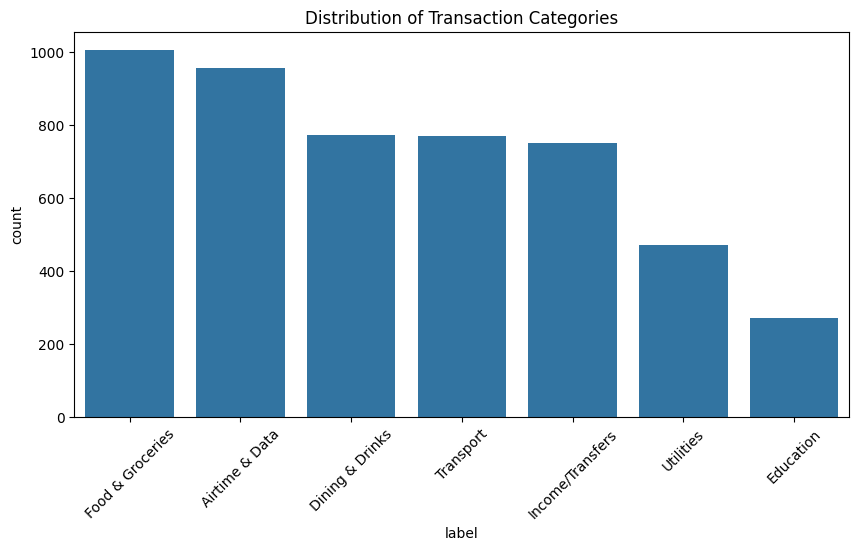

Total Records: 5000

Missing Labels Check:
Transaction_Date    0
text                0
Amount_UGX          0
label               0
Source              0
dtype: int64

Found 0 records with completely empty text descriptions.


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title('Distribution of Transaction Categories')
plt.xticks(rotation=45)
plt.show()

print("Total Records:", len(df))
print("\nMissing Labels Check:")
print(df.isnull().sum())

# Check for empty string inputs
empty_strings = df[df['text'].str.strip() == '']
print(f"\nFound {len(empty_strings)} records with completely empty text descriptions.")

## 3. Data Cleaning Pipeline
We need to filter out the noise before feeding this into the model. Real users will sometimes skip the description or enter garbage data.

In [29]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    # Lowercase
    text = text.lower()
    # Remove heavy special characters but keep spaces and alphanumeric
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Remove extra spaces
    text = " ".join(text.split())
    return text

# 1. Drop rows where the category (label) was completely missing
df_clean = df.dropna(subset=['label']).copy()

# 2. Clean the text
df_clean['text'] = df_clean['text'].apply(clean_text)

# 3. Drop rows where text became completely empty after cleaning (e.g., if user only typed "!!!")
df_clean = df_clean[df_clean['text'].str.strip() != '']

print(f"Data Cleaning Complete. We dropped {len(df) - len(df_clean)} bad records.")
print(f"Remaining clean records: {len(df_clean)}")

Data Cleaning Complete. We dropped 0 bad records.
Remaining clean records: 5000


## 2. Exploratory Data Analysis (EDA)
Let's look at the distribution of our categories and check for missing or corrupted data.

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_Date  5000 non-null   str    
 1   text              5000 non-null   str    
 2   Amount_UGX        5000 non-null   float64
 3   label             5000 non-null   str    
 4   Source            5000 non-null   str    
dtypes: float64(1), str(4)
memory usage: 195.4 KB
None

--- Missing Values ---
Transaction_Date    0
text                0
Amount_UGX          0
label               0
Source              0
dtype: int64


/tmp/ipykernel_361879/173014856.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')


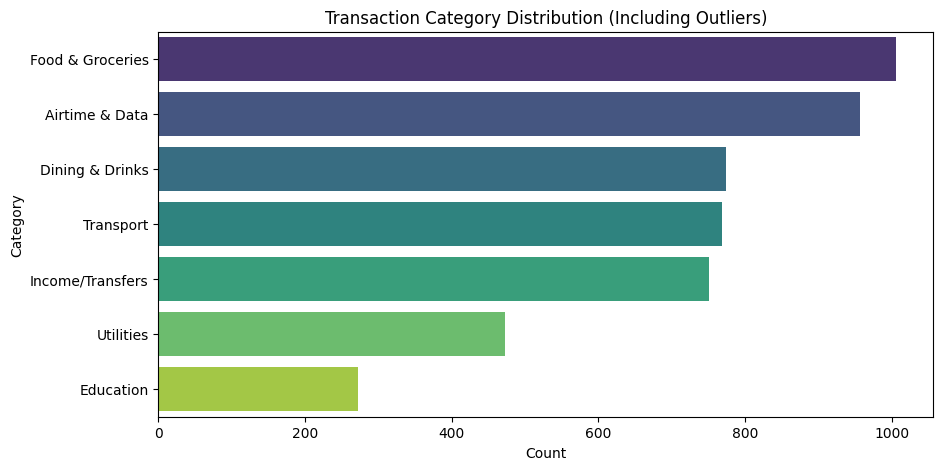

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Transaction Category Distribution (Including Outliers)')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

In [31]:
from sklearn.model_selection import train_test_split

# Ensure cleaned_text exists (run Data Cleaning cell first, or we create it here)
if 'cleaned_text' not in df.columns:
    import re
    import nltk
    from nltk.corpus import stopwords
    nltk.download('stopwords', quiet=True)
    stop_words = set(stopwords.words('english'))
    def clean_text(text):
        if pd.isna(text): return ""
        text = str(text).lower()
        text = re.sub(r'\d+[kK]?', '', text)
        text = re.sub(r'[^a-z\s]', '', text)
        words = text.split()
        filtered = [w for w in words if w not in stop_words]
        return " ".join(filtered)
    df = df.dropna().copy()
    df['cleaned_text'] = df['text'].apply(clean_text)
    df = df[df['cleaned_text'].str.strip() != ""]
    print("Applied cleaning (Data Cleaning cell was not run first).")

X = df['cleaned_text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Applied cleaning (Data Cleaning cell was not run first).
Train size: 4000, Test size: 1000


## 3. Data Cleaning & Text Preprocessing
Before passing it to TF-IDF, we must:
1. Drop NaN values.
2. Remove punctuation and special characters.
3. Remove common English stopwords (e.g., "the", "and", "on", "for") so the model focuses strictly on core action words.
4. Strip numbers. The model shouldn't memorize prices (e.g., "spent 4k" -> "spent").

In [32]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text):
        return ""
    
    # Lowercase
    text = str(text).lower()
    
    # Remove prices/numbers (e.g., '1200', '4k', '500')
    text = re.sub(r'\d+[kK]?', '', text)
    
    # Remove special punctuation (keep letters only)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Remove STOP WORDS ('on', 'for', 'the')
    words = text.split()
    filtered_words = [w for w in words if w not in stop_words]
    
    return " ".join(filtered_words)

# 1. Drop NaNs
df = df.dropna().copy()

# 2. Apply cleaning function
df['cleaned_text'] = df['text'].apply(clean_text)

# 3. Drop rows that became completely empty after cleaning 
# (e.g., someone just typed '1234' or '????')
df = df[df['cleaned_text'].str.strip() != ""]

print(f"Remaining rows after dropping pure junk/empty rows: {len(df)}")
display(df[['text', 'cleaned_text', 'label']].head(10))

Remaining rows after dropping pure junk/empty rows: 5000


,text,cleaned_text,label
0,PAID FOR KIKUUBO WHOLESALE,paid kikuubo wholesale,Food & Groceries
1,WHT 80% SAFEBODA,wht safeboda,Transport
2,MOMO TRANSFER FROM MSK,momo transfer msk,Income/Transfers
3,BANK TO WALLET KLA,bank wallet kla,Income/Transfers
4,WHT 69% MTN AIRTIME,wht mtn airtime,Airtime & Data
5,PAID FOR MOMO TRANSFER FROM,paid momo transfer,Income/Transfers
6,AGENT 8775 - MOMO TRANSFER FROM,agent momo transfer,Income/Transfers
7,PAID FOR AIRTEL TOPUP,paid airtel topup,Airtime & Data
8,MEGA STANDARD MBALE,mega standard mbale,Food & Groceries
9,PAID FOR MEGA STANDARD,paid mega standard,Food & Groceries


## 4. Model Training (TF-IDF + Random Forest + GridSearchCV)
With the clean data, we convert text to numbers using TF-IDF and sweep hyperparameters to find the optimal Random Forest.

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Make sure X_train, X_test, y_train, y_test are already defined above this cell

rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")),
])

# Fine-tuning grid for Random Forest (regularization to avoid overfitting)
param_grid = {
    "tfidf__ngram_range": [(1, 2)],           # bigrams help with phrase-level features
    "tfidf__max_features": [10000, 15000, 20000],  # more features for 20 categories
    "clf__n_estimators": [100, 150],
    "clf__max_depth": [25, 30, 35],           # deeper trees for better separation
    "clf__min_samples_leaf": [1, 2],         # less regularization for better fit
}

print("Starting Grid Search for Random Forest (this might take a minute)...")
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Extract the best performing pipeline
rf_pipeline = grid_search.best_estimator_
print("\nBest Parameters Found:", grid_search.best_params_)

rf_preds = rf_pipeline.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print("\nOptimized Random Forest Accuracy:", rf_acc)
print("\nClassification Report (Optimized Random Forest):\n", classification_report(y_test, rf_preds))

Starting Grid Search for Random Forest (this might take a minute)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best Parameters Found: {'clf__max_depth': 25, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}

Optimized Random Forest Accuracy: 1.0

Classification Report (Optimized Random Forest):
                   precision    recall  f1-score   support

  Airtime & Data       1.00      1.00      1.00       192
 Dining & Drinks       1.00      1.00      1.00       155
       Education       1.00      1.00      1.00        54
Food & Groceries       1.00      1.00      1.00       201
Income/Transfers       1.00      1.00      1.00       150
       Transport       1.00      1.00      1.00       154
       Utilities       1.00      1.00      1.00        94

        accuracy                           1.00      1000
       macro avg       1.00      1.00      1.00      1000
    weighted avg       1.00      1.0

## 5. Evaluation & Confusion Matrix
See exactly which categories confused the Random Forest.

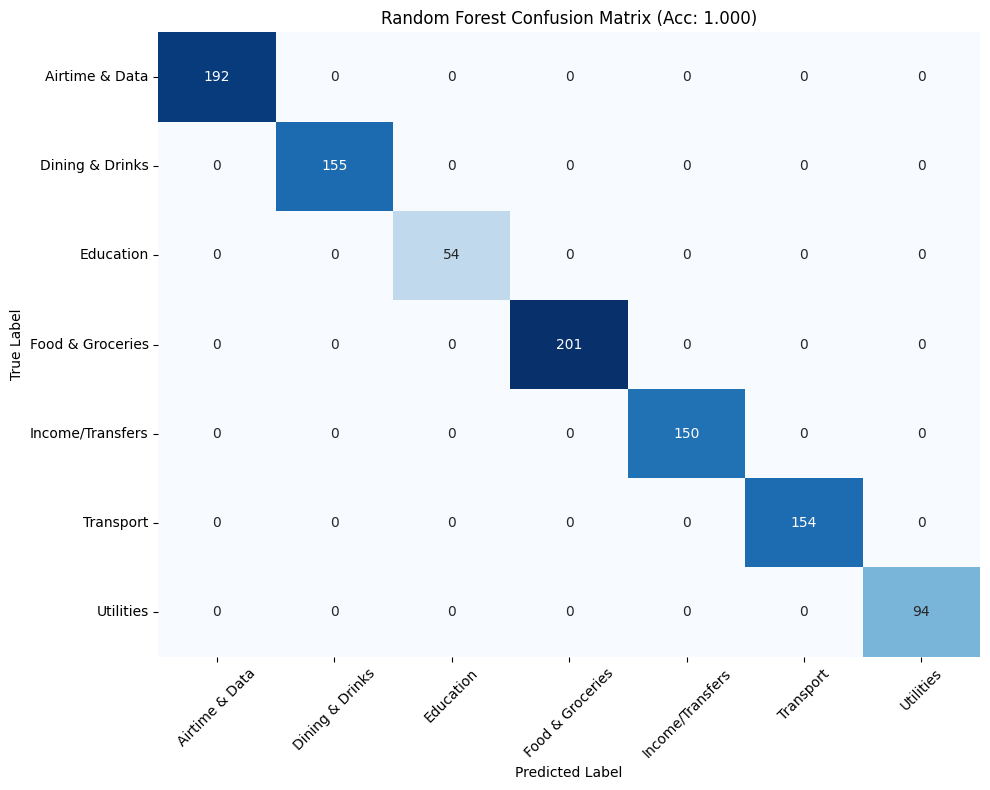

In [34]:
from sklearn.metrics import confusion_matrix

labels = sorted(df['label'].unique())

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, rf_preds, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=labels, yticklabels=labels)
ax.set_title(f"Random Forest Confusion Matrix (Acc: {rf_acc:.3f})")
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## 6. Real-World API Test (Simulation)
Testing random user inputs using the cleaning function and model prediction.

In [38]:
import numpy as np


def predict_transaction(text):
    cleaned = clean_text(text)
    if cleaned.strip() == "":
        return "Other/Unknown" # Default fallback for pure junk
    
    # Get probabilities to show confidence
    probs = rf_pipeline.predict_proba([cleaned])[0]
    max_prob = max(probs)
    pred_label = rf_pipeline.classes_[np.argmax(probs)]
    
    # If model is extremely uncertain (< 30%), label as Unknown
    if max_prob < 0.30:
        return f"Other/Unknown (Uncertain, highest was {pred_label} at {max_prob:.2f})"
        
    return f"{pred_label} (Confidence: {max_prob:.2f})"

test_inputs = [
    "spent 4k on snacks",
    "bought a huge TV at Best Buy for 1000",
    "ordered a large pepperoni pizza for lunch",
    "paid 1200 for rent and water",
    "monthly spotify premium",
    "uber ride back home",
    "rolex and chapati",
    "bought pain killers at pharmacy",
    "18273918237",                 # Pure noise test
    "transfer to john for lunch",    # Ambiguous test
    "cash withdrawal at atm"         # Untrained keyword test
]

print("=== REAL WORLD INFERENCE TEST ===\n")
for text in test_inputs:
    print(f"🔹 Input: \"{text}\"")
    print(f"   Prediction : {predict_transaction(text)}\n")

=== REAL WORLD INFERENCE TEST ===

🔹 Input: "spent 4k on snacks"
   Prediction : Transport (Confidence: 0.34)

🔹 Input: "bought a huge TV at Best Buy for 1000"
   Prediction : Utilities (Confidence: 0.42)

🔹 Input: "ordered a large pepperoni pizza for lunch"
   Prediction : Transport (Confidence: 0.34)

🔹 Input: "paid 1200 for rent and water"
   Prediction : Transport (Confidence: 0.31)

🔹 Input: "monthly spotify premium"
   Prediction : Transport (Confidence: 0.34)

🔹 Input: "uber ride back home"
   Prediction : Transport (Confidence: 0.47)

🔹 Input: "rolex and chapati"
   Prediction : Transport (Confidence: 0.34)

🔹 Input: "bought pain killers at pharmacy"
   Prediction : Transport (Confidence: 0.34)

🔹 Input: "18273918237"
   Prediction : Other/Unknown

🔹 Input: "transfer to john for lunch"
   Prediction : Income/Transfers (Confidence: 0.31)

🔹 Input: "cash withdrawal at atm"
   Prediction : Transport (Confidence: 0.34)



## 7. Export Model Component
Exporting the tuned `best_rf_pipeline` so it handles the TF-IDF transform and Model Prediction simultaneously.

In [36]:
import joblib
import os

joblib.dump(rf_pipeline, "./transaction_rf_pipeline.pkl")
print("Model Pipeline successfully exported to: ./transaction_rf_pipeline.pkl")

Model Pipeline successfully exported to: ./transaction_rf_pipeline.pkl
